In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

from src.data_generation import SimulationConfig, generate_dataset

In [2]:
config = SimulationConfig(
    n_customers=5000,
    n_transactions=100000,
    fraud_rate_target=0.03,
    random_state=42
)

df = generate_dataset(config)
df.head()

,transaction_id,customer_id,timestamp,transaction_type,merchant_category,transaction_amount,merchant_id,channel,device_type,device_id,...,is_foreign_transaction,channel_risk,category_risk,high_amount_new_device,foreign_high_risk_merchant,web_night_transaction,very_high_amount_foreign,fraud_risk_score,fraud_probability,is_fraud
0,TXN_0000001,CUST_000861,2025-02-02 11:00:00,card,fuel,42.32,MERCH_00441,pos,ios,DEV_002799,...,1,0.30,0.15,0,0,0,0,-3.043349,0.008191,0
1,TXN_0000002,CUST_003773,2025-10-09 18:00:00,digital_payment,fashion,57.90,MERCH_00414,web,android,DEV_013863,...,1,1.20,0.55,0,0,0,0,-1.663994,0.028661,1
2,TXN_0000003,CUST_003093,2025-08-27 06:00:00,digital_payment,restaurants,29.67,MERCH_00269,pos,android,DEV_010056,...,0,0.30,0.25,0,0,0,0,-3.387342,0.005885,0
3,TXN_0000004,CUST_000467,2025-06-09 18:00:00,digital_payment,grocery,52.43,MERCH_00191,app,android,DEV_001720,...,1,0.75,0.20,0,0,0,0,-2.320802,0.016095,0
4,TXN_0000005,CUST_004427,2025-06-07 15:00:00,digital_payment,gaming,64.67,MERCH_00257,web,android,DEV_014495,...,1,1.20,1.00,0,0,0,0,-1.532862,0.031964,0


In [3]:
print("Shape:", df.shape)
print("Fraud rate:", round(df["is_fraud"].mean(), 4))
df["is_fraud"].value_counts(normalize=True)

Shape: (100000, 40)
Fraud rate: 0.0333


is_fraud
0    0.9667
1    0.0333
Name: proportion, dtype: float64

In [4]:
df["transaction_amount"].describe()

count    100000.000000
mean         52.252057
std          52.900465
min           1.630000
25%          25.570000
50%          37.080000
75%          57.370000
max        2091.480000
Name: transaction_amount, dtype: float64

<Axes: >

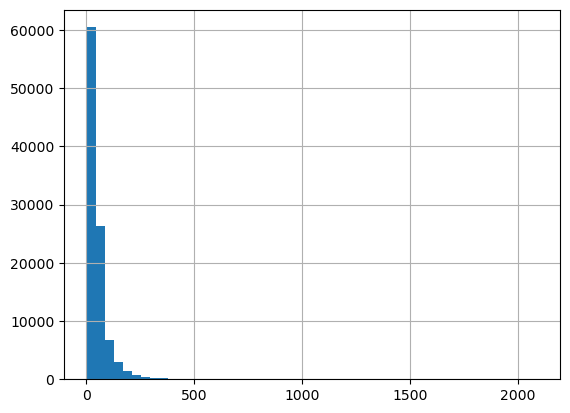

In [5]:
df["transaction_amount"].hist(bins=50)

In [6]:
df.groupby("merchant_category")["transaction_amount"].describe()[["mean", "50%", "max"]]

,mean,50%,max
merchant_category,,,
electronics,101.208440,81.960,2091.48
fashion,65.398323,54.855,565.42
fuel,28.830578,27.150,93.66
gaming,28.546696,24.620,232.59
grocery,36.770778,33.340,272.04
restaurants,34.035701,30.175,214.89
travel,127.574583,99.790,1134.56
utilities,42.293076,40.390,123.67


In [7]:
df.groupby("channel")["transaction_amount"].describe()[["mean", "50%", "max"]]

,mean,50%,max
channel,,,
app,52.497397,37.13,1151.81
pos,51.726031,36.96,1101.69
web,52.195563,37.06,2091.48


In [8]:
df.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False)

merchant_category
electronics    0.064539
gaming         0.058518
travel         0.056917
fashion        0.028579
grocery        0.022793
restaurants    0.021933
fuel           0.021362
utilities      0.019168
Name: is_fraud, dtype: float64

In [10]:
df.groupby("channel")["is_fraud"].agg(
    transactions="count",
    fraud_cases="sum",
    fraud_rate="mean"
).sort_values("fraud_rate", ascending=False)

,transactions,fraud_cases,fraud_rate
channel,,,
web,30161,1377,0.045655
app,49835,1523,0.030561
pos,20004,430,0.021496


In [11]:
df.isnull().sum().sort_values(ascending=False).head(10)

transaction_id           0
customer_id              0
declines_last_30d        0
chargebacks_last_90d     0
amount_vs_avg_ratio      0
is_high_amount           0
is_very_high_amount      0
is_night_transaction     0
is_high_risk_merchant    0
is_new_device            0
dtype: int64

In [12]:
df.dtypes

transaction_id                        object
customer_id                           object
timestamp                     datetime64[ns]
transaction_type                      object
merchant_category                     object
transaction_amount                   float64
merchant_id                           object
channel                               object
device_type                           object
device_id                             object
transaction_city                      object
merchant_risk_score                  float64
hour                                   int32
day_of_week                            int32
is_weekend                             int64
customer_home_city                    object
customer_tenure_days                   int64
account_age_days                       int64
preferred_device_type                 object
avg_amount_30d                       float64
std_amount_30d                       float64
transactions_last_7d                   int64
declines_l